In [9]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib import cm

from src import loader, plotter
from datetime import timedelta

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.fdu import functional_dynamic_update
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

from src.fdu_v2 import functional_dynamic_update

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 48
method = 'fusion'
resource = 'wind'
aggregation = 'zone'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# wind unbiased-025-0 {6: 1, 12: 2, 18: 2}
# wind unbiased-025-1 {6: 1, 12: 4, 18: 1}
# wind unbiased-025-2 {6: 2, 12: 1, 18: 1}
# wind biased-025 {6: 4, 12: 4, 18: 4}
exp_description="unbiased-025"

#_init = {6: 1, 12: 2, 18: 2}
#_init = {6: 4, 12: 4, 18: 1}
#_init = {6: 2, 12: 1, 18: 1}
_init = {6: 1, 12: 4, 18: 5}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation=VALIDATION,
)

# hyper_.loc['clique_order'] = 0
# hyper_.loc['clique_order'] = 1
# hyper_.loc['clique_order'] = 2
print(hyper_)

# stats_ = loader.get_stats(
#     _init, 
#     resource, 
#     method, 
#     aggregation, 
#     exp_description, 
#     T, 
#     VALIDATION, 
# )
# # print(stats_)

table, latex = loader.envelope_table(
    _init, 
    hyper_, 
    envelope_, 
    path_to_validation=VALIDATION
)
# print(table)

file_name = TABLES / f"{resource}_{method}_{aggregation}_{exp_description}-envelope.tex"
with open(file_name, "w") as _f:
    _f.write(latex)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/Guille/Desktop/dynamic_update/validation/wind/wind_fusion_zone-hyper-unbiased-025.csv'

In [218]:
zone = 0

(F_tr_, F_ts_, 
 E_tr_, E_ts_, 
 d_tr_, d_ts_, 
 t_tr_, t_ts_, 
 X_tr_, X_ts_, 
 dt_, regions_, region
) = loader.processed_zone_dataset(
    path_to_data = DATA / "gridstatus/processed_ERCOT_wind_data_v4.pkl",
    zone = zone,
    N_test_samples = 360,
    unbiased = True
)

print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(d_tr_.shape, d_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(dt_.shape)
print(region)

(1974, 24, 72) (360, 24, 72)
(1974, 24, 48) (360, 24, 48)
(1974,) (360,)
(1974, 24, 72) (360, 24, 72)
(1974, 2) (360, 2)
(72,)
Coastal


Coastal Sep 7 7am
(1974, 72) (1974, 72)
(24,) (48,) (48,) (72,)
(150,)
(150,)
8.043777673586309e-14 2 345 13
wind-Coastal-250-12-zone
(72,) (1974, 72)


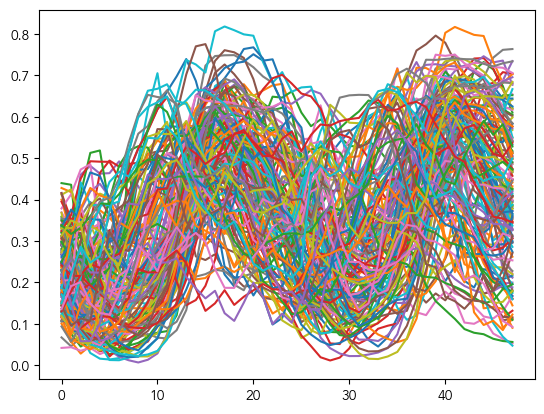

In [219]:
day = 250
interval = 12


dx_ = np.array([
    (
        t_ts + timedelta(minutes=0)
    ).strftime('%b %-d %-I%p').replace('AM', 'am').replace('PM', 'pm') 
    for t_ts in t_ts_[day, interval]
])

_fdu = functional_dynamic_update(
    _distances = {'temporal': 'seasonal_equinox', 'spatial': 'graph', 'fusion': 'None'},
    name = region,
    date = dx_[24],
)
print(_fdu.name, _fdu.date)

F_tr_p_ = F_tr_[:, interval, :]
E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
print(F_tr_p_.shape, E_tr_p_.shape)

_fdu.fit(
    F_tr_p_, E_tr_p_, dt_, 
    X_ = X_tr_, 
    t_ = d_tr_, 
    n_samples_per_hour=1,
)

f_ = F_ts_[day, interval, :24]
f_hat_ = F_ts_[day, interval, 24:]
e_ = E_ts_[day, interval, ...]
e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
print(f_.shape, f_hat_.shape, e_.shape, e_p_.shape)

M_ = _fdu.predict(
    f_, e_p_, X_ts_[day], d_ts_[day],
    clique_order = 1.,
    forget_rate_f = .5,
    forget_rate_e = 1.,
    lookahead_rate = 16.,
    length_scale_f = 1000.,
    length_scale_e = 80.,
    length_scale_d = 3.,
    sigma = .2,
    nu = 16.,
    kappa_0 = 150,
    kappa = 150,
    p_fusion = 1.,
)
print(_fdu.idx_fed_.shape)
print(_fdu.idx_x_.shape)
print(_fdu.xi, _fdu.r, _fdu.t_max, _fdu.t_min)

file_name = f"{resource}-{region}-{day}-{interval}-zone"
print(file_name)

e_p_[:24] = np.nan
E_tr_p_[:, :24] = np.nan
print(e_p_.shape, E_tr_p_.shape)
    
plt.figure()
plt.plot(M_.T)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


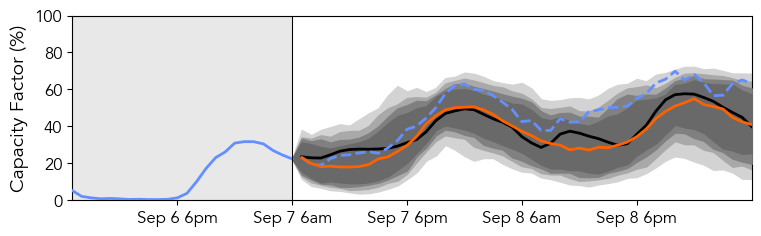

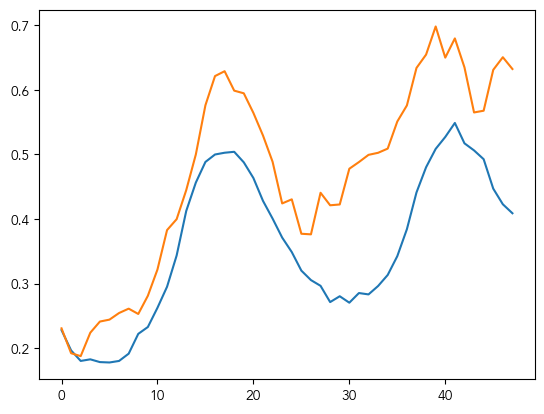

In [220]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]

f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(_fdu.M_ext_, alpha_)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_median_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    color=palette_.loc[3, "ibm"],
    CR="CI",
    label=r"$\bar{\mu} (s)$",
    range_=[0, 71],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .825),
    fontsize = 12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol = 5
)

plt.savefig(IMAGES / f"EDF-{file_name}.pdf")

plt.show()

plt.figure()
plt.plot(f_median_ext_[1:])
plt.plot(f_hat_)

plt.show()

In [49]:
pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description="unbiased-025",
    path_to_validation = VALIDATION
)

print(pit_.shape)

_fig, _ax = plt.subplots(figsize = (2.25, 2.25), constrained_layout = True)

lead = 1
plotter.plot_pit(
    _fig, _ax, pit_[:, lead:(lead + 2)].flatten(), 
    v = 0.4,
    bins = 10,
    xlabel = 'PIT (1h to 3h lead)'
)

#plt.savefig(path_to_images / f"PIT-{resource}-{lead}-{bins}-{interval}.pdf")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/Guille/Desktop/dynamic_update/validation/wind/wind_fusion_zone-PIT_18-unbiased-025.csv'

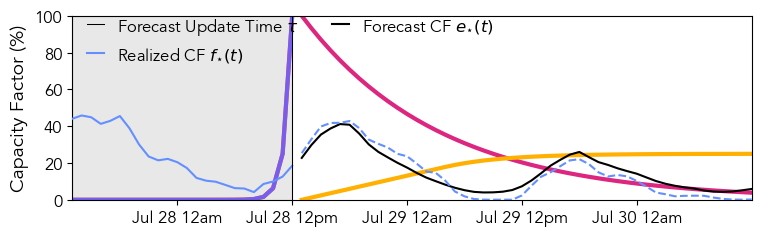

In [79]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_forecast_parameters(
    _fig, _ax, palette_,
    _fdu.phi_, _fdu.psi_, _fdu.eta_,
    f_, f_hat_, e_p_, dx_, dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    labels_1=True,
    labels_2=False,
)

_ax.legend(frameon=False,
           ncol=2,
           loc=(0.0125,0.7),
           #loc=(0.362,0.625),
           fontsize=12)

plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

AttributeError: 'functional_dynamic_update' object has no attribute 'idx_spatial_'

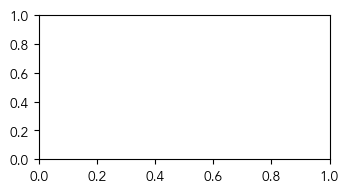

In [80]:
# Plot
_fig, _ax = plt.subplots(figsize = (3.75, 1.875))

plotter.plot_zone_neighborhood(
    _fig, _ax, palette_,
    X_tr_, regions_, _fdu.idx_spatial_, region
)

plt.savefig(IMAGES / f"region_neighbors-{file_name}.pdf")

plt.show()

2025-07-28 01:00:00-05:00


AttributeError: 'functional_dynamic_update' object has no attribute 'idx_neighbors_'

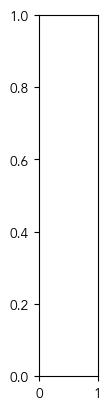

In [30]:
_fig, _ax = plt.subplots(figsize=(1, 4), constrained_layout=True)

print(t_ts_[day, interval, 12])
plotter.scenarios_frequency_dates(
    _fig, _ax, palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_,
    t_tr_[:, interval, 12],
    t_ts_[day, interval, 12], 
    scale=1,
    colorbar=True,
)

plt.savefig(IMAGES / f"temporal_neiboring_assets-{file_name}.pdf")

plt.show()

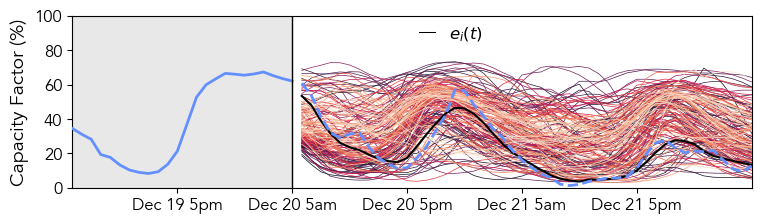

In [173]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_forecasts(
    _fig, _ax, palette_, 
    E_tr_p_, _fdu.w_fed_, _fdu.idx_x_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend=False,
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

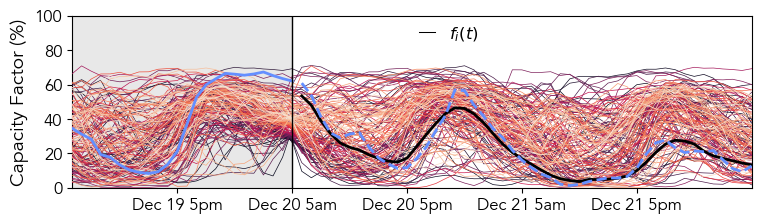

In [174]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_neighbors(
    _fig, _ax, palette_, 
    F_tr_p_, _fdu.w_fed_, _fdu.idx_x_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

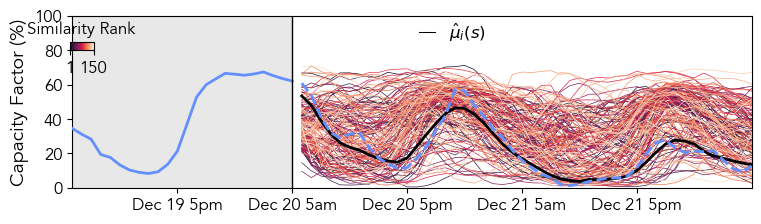

In [175]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_updates(
    _fig, _ax, palette_, M_, f_, f_hat_, e_p_, _fdu.w_fed_, _fdu.idx_x_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

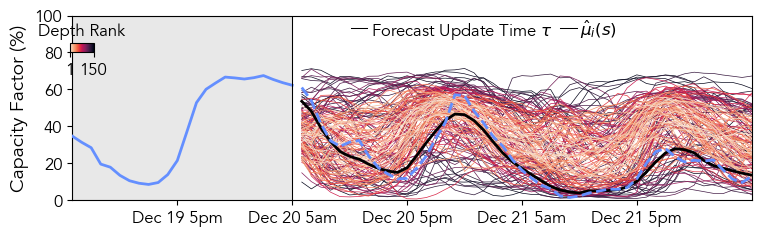

In [176]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

depth = "MBD"
depth_rank_ = _fDepth(_fdu.M_, depth, DEPTH).to_numpy()[:, 0]

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_p_, depth_rank_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    colorbar=True,
)

_ax.legend(frameon = False,
           loc = (0.4, .825),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.2,
           ncol = 5)

plt.savefig(IMAGES / f"ranking-{depth}_{file_name}.pdf")

plt.show()

In [178]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

k_ = get_band_fraction(envelope_, alpha_, interval, distance, score)

J_ = _fdu.focal_curve_envelope(_depth, _fdu.M_ext_, distance)

f_focal_ext_, _upper, _lower = _fdu.focal_envelopd_confidence_bands(alpha_, k_)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    color=palette_.loc[4, "ibm"],
    label=r"$\bar{f} (s)$",
    CR="CR",
    range_=[0, 71],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon=False,
    loc=(0.1875, 0.825),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=5,
)

plt.savefig(IMAGES / f"focal_curve_envelop-{file_name}.pdf")

plt.show()

NameError: name 'envelope_' is not defined

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


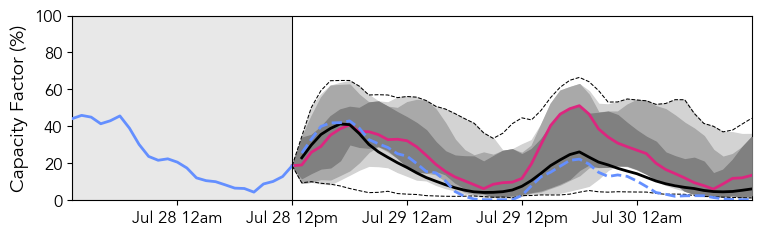

In [16]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(_fdu.M_ext_, depth_rank_)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .825),
    fontsize = 12,
    columnspacing=0.5,
    handletextpad=0.2,
    ncol = 6
)

plt.savefig(IMAGES / f"fboxplot-{depth}_{file_name}.pdf")

plt.show()

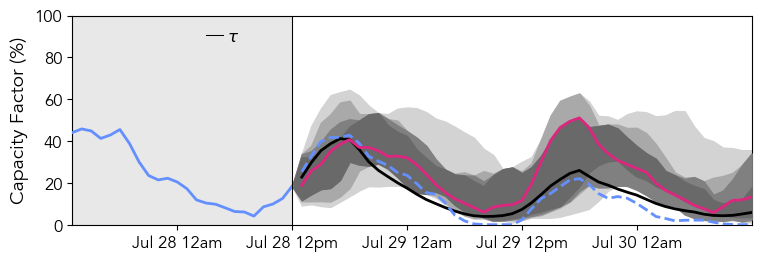

In [19]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

k_ = get_band_fraction(envelope_, alpha_, interval, distance, score)

f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(_depth, _fdu.M_ext_, alpha_, k_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval=24,
    n=720,
    color=palette_.loc[2, "ibm"],
    label=r"$\bar{f} (s)$",
    CR="CR",
    range_=[0, 71],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon=False,
    loc=(0.1875, 0.825),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=5,
)

plt.savefig(IMAGES / f"{distance}_bands-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


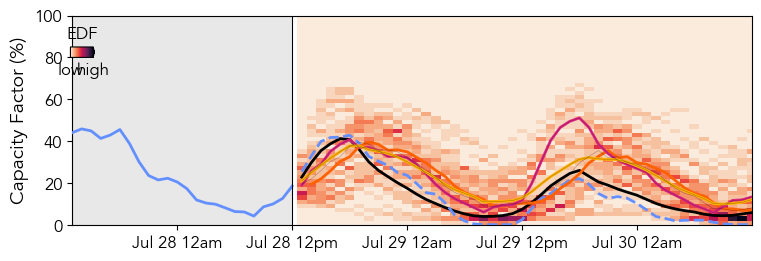

In [20]:
_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

plotter.plot_density_heatmap(
    _fig, _ax, palette_,
    M_, f_median_ext_, f_deepest_ext_, f_focal_ext_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n=720,
    range_=[0, 71],
    colorbar=True,
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .8),
    fontsize = 12,
    ncol = 3
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

In [21]:
print(F_ts_.shape)

(360, 24, 72)


In [46]:
day = 100
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

F_curves_ = []
E_curves_ = []
M_curves_ = []
D_curves_ = []
dxs_ = []
dts_ = []

for interval in range(24):

    dx_ = np.array([
        (
            t_ts + timedelta(minutes=0)
        ).strftime('%b %-d %-I%p').replace('AM', 'am').replace('PM', 'pm') 
        for t_ts in t_ts_[day, interval]
    ])

    F_tr_p_ = F_tr_[:, interval, :]
    E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
    #print(F_tr_p_.shape, E_tr_p_.shape)
    
    _fdu.fit(
        F_tr_p_, E_tr_p_, dt_, 
        X_ = X_tr_, 
        t_ = d_tr_, 
        n_samples_per_hour=1,
    )

    f_ = F_ts_[day, interval, :24]
    f_hat_ = F_ts_[day, interval, 24:]
    e_ = E_ts_[day, interval, ...]
    e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
    #print(f_.shape, f_hat_.shape, e_.shape, e_p_.shape)
    
    M_ = _fdu.predict(
        f_, e_p_, X_ts_[day], d_ts_[day],
        clique_order = get_hyper(hyper_, 'clique_order', interval),
        forget_rate_f = get_hyper(hyper_, 'forget_rate_f', interval),
        forget_rate_e = get_hyper(hyper_, 'forget_rate_e', interval),
        length_scale_f = 1./get_hyper(hyper_, 'length_scale_f', interval),
        length_scale_e = 1./get_hyper(hyper_, 'length_scale_e', interval),
        lookup_rate =  get_hyper(hyper_, 'lookup_rate', interval),
        trust_rate = get_hyper(hyper_, 'trust_rate', interval),
        nu = get_hyper(hyper_, 'nu', interval),
        xi = get_hyper(hyper_, 'xi', interval),
        gamma = get_hyper(hyper_, 'gamma', interval),
        kappa = get_hyper(hyper_, 'kappa', interval),
        p_fusion = get_hyper(hyper_, 'p_fusion', interval)
    )

    f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(_fdu.M_ext_, alpha_)

    k_ = get_band_fraction(
        envelope_, 
        alpha_, 
        interval, 
        "MBD", 
        "FCS",
    )
    
    f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(
        _depth, 
        _fdu.M_ext_, 
        alpha_, 
        k_
    )
    
    k_ = get_band_fraction(
        envelope_, 
        alpha_, 
        interval, 
        "fknn", 
        "FCS",
    )
    
    J_ = _fdu.focal_curve_envelope(
        _depth, 
        _fdu.M_ext_, 
        "fknn"
    )
    
    #f_focal_ext_, _upper, _lower = _fdu.focal_envelop_confidence_bands(alpha_, k_)

    M_curves_.append(f_median_ext_)
    E_curves_.append(e_)
    D_curves_.append(f_deepest_ext_)
    F_curves_.append(f_hat_)

    dts_.append(dt_ + interval*60)
    dxs_.append(dx_)

print(len(F_curves_), len(M_curves_), len(D_curves_), len(dts), len(dxs))

24 24 24 24 24


In [30]:
# _fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

# # for i in range(12):
# #     plt.plot(dxs[i][24:], M_curves_[i][1:])
# #     #plt.plot(dxs[i][24:], E_curves_[i])
# #     plt.plot(dxs[i][24:], F_curves_[i], color = 'k')

# # plt.ylim(0,1)
# # plt.show()

# print(dt_)

(95,) (95,)
['Apr 5 10pm' 'Apr 5 11pm' 'Apr 5 7pm' 'Apr 5 8pm' 'Apr 5 9pm'
 'Apr 6 10am' 'Apr 6 10pm' 'Apr 6 11am' 'Apr 6 11pm' 'Apr 6 12am'
 'Apr 6 12pm' 'Apr 6 1am' 'Apr 6 1pm' 'Apr 6 2am' 'Apr 6 2pm' 'Apr 6 3am'
 'Apr 6 3pm' 'Apr 6 4am' 'Apr 6 4pm' 'Apr 6 5am' 'Apr 6 5pm' 'Apr 6 6am'
 'Apr 6 6pm' 'Apr 6 7am' 'Apr 6 7pm' 'Apr 6 8am' 'Apr 6 8pm' 'Apr 6 9am'
 'Apr 6 9pm' 'Apr 7 10am' 'Apr 7 10pm' 'Apr 7 11am' 'Apr 7 11pm'
 'Apr 7 12am' 'Apr 7 12pm' 'Apr 7 1am' 'Apr 7 1pm' 'Apr 7 2am' 'Apr 7 2pm'
 'Apr 7 3am' 'Apr 7 3pm' 'Apr 7 4am' 'Apr 7 4pm' 'Apr 7 5am' 'Apr 7 5pm'
 'Apr 7 6am' 'Apr 7 6pm' 'Apr 7 7am' 'Apr 7 7pm' 'Apr 7 8am' 'Apr 7 8pm'
 'Apr 7 9am' 'Apr 7 9pm' 'Apr 8 10am' 'Apr 8 10pm' 'Apr 8 11am'
 'Apr 8 11pm' 'Apr 8 12am' 'Apr 8 12pm' 'Apr 8 1am' 'Apr 8 1pm'
 'Apr 8 2am' 'Apr 8 2pm' 'Apr 8 3am' 'Apr 8 3pm' 'Apr 8 4am' 'Apr 8 4pm'
 'Apr 8 5am' 'Apr 8 5pm' 'Apr 8 6am' 'Apr 8 6pm' 'Apr 8 7am' 'Apr 8 7pm'
 'Apr 8 8am' 'Apr 8 8pm' 'Apr 8 9am' 'Apr 8 9pm' 'Apr 9 10am' 'Apr 9 11am'
 'Ap

(72,)


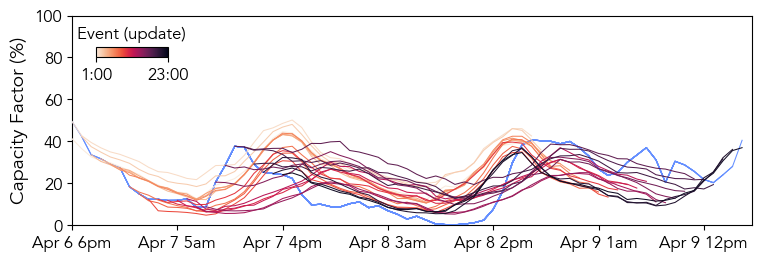

In [83]:
def plot_zonal_dynamic_update(
    _fig,
    _ax,
    palette_,
    F_curves_,
    M_curves_,
    dxs_,
    dts_,
    legend=False,
    colorbar=True,
    label=r"$\bar{f} (s)$",
    n = 120,
    range_=[],
):

    dx = np.unique(np.array(dxs_).flatten())[:-23]
    dt = np.unique(np.array(dts_).flatten())[:-23]

    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(0.0, len(F_curves_))

    _ax.plot(
        [], [], 
        lw=0.75, 
        label=label if legend else None, 
        c="k"
    )

    for i in range(len(F_curves_)):
        _ax.plot(
            dts_[i][:-24],
            100*F_curves_[i],
            c=palette_.loc[0, "ibm"],
            lw=0.75,
            zorder=8,
        )
        
    for i in range(len(M_curves_)):
        _ax.plot(
            dts_[i][:-23] - 60,
            100*M_curves_[i],
            c=_cmap(_norm(i)),
            lw=0.75,
            zorder=8,
        )

    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
    
    _ax.set_ylim(0, 100)
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[1]])

    _ax.tick_params(axis="both", labelsize=12)

    if colorbar:
        cbar = _fig.colorbar(
            cm.ScalarMappable(_norm, _cmap),
            cax=_ax.inset_axes([150, 80, 450, 5], transform=_ax.transData),
            orientation="horizontal",
        )

        cbar.set_ticks([0, len(F_curves_)], labels=["1:00", "23:00"], size=12)

        # cbar.ax.tick_params(length=0)

        cbar.ax.set_title("Event (update)", rotation=0, size=12)


print(dts_[0].shape)
_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

plot_zonal_dynamic_update(
    _fig, _ax, palette_, F_curves_, M_curves_, dxs_, dts_, 
    range_=[0, 71],
    n = 220)

plt.show()